# Content Representation & Similarity 

## Data collection 

Based on the MMDS readings and discussion in class, I wondered if using different song features (e.g., title, lyrics, tempo) would result in different embeddings, and as a result, different recommendations. 

The dataset used here is retrieved from https://www.kaggle.com/datasets/bwandowando/spotify-songs-with-attributes-and-lyrics.
The author collected the data by querying the Spotify API and combining multiple sources together. 
Data columns are described in `data/dataset_description.md`

## Module 0: Data Exploration

Before building any models, we need to understand the data we're working with.
This module answers three questions:
1. **What is in the dataset?** (schema, size, missing values)
2. **What do the features look like?** (distributions, correlations)
3. **What quirks should we watch for?** (skew, sparsity, dominant artists)

We work with a random sample of **N_SAMPLE = 25,000** songs from a ~955K-track Spotify dataset
that includes audio features (danceability, energy, tempo, …) and lyrics scraped from Genius.

## 0. Take a peak

Let's first take a peak at it and check for missing values, value ranges and clean the data

In [1]:
import pandas as pd

# ── Paths & parameters ────────────────────────────────────────────────────────
DATA_PATH = "data/spotify/songs_with_attributes_and_lyrics.csv"
N_SAMPLE  = 25_000

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()

,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,lyrics
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,HELLYEAH,0.415,0.6050,7,-11.157,1,0.0575,0.00116,0.838000,0.4710,0.193,100.059,79500.0,"He said he came from Jamaica,\n he owned a cou..."
1,2ASl4wirkeYm3OWZxXKYuq,!!,NaN,Yxngxr1,0.788,0.6480,7,-9.135,0,0.3150,0.90000,0.000000,0.1760,0.287,79.998,114000.0,"Fucked a bitch, now she running with my kids\n..."
2,69lcggVPmOr9cvPx9kLiiN,!!! - Interlude,Where I Belong EP,Glowie,0.000,0.0354,7,-20.151,0,0.0000,0.90800,0.000000,0.4790,0.000,0.000,11413.0,"Oh, my God, I'm going crazy\n"
3,4U7dlZjg1s9pjdppqZy0fm,!!De Repente!!,Un Palo Al Agua (20 Grandes Canciones),Rosendo,0.657,0.8820,5,-6.340,1,0.0385,0.00740,0.000013,0.0474,0.939,123.588,198173.0,Continuamente se extraña la gente si no puede ...
4,4v1IBp3Y3rpkWmWzIlkYju,!!De Repente!!,Fuera De Lugar,Rosendo,0.659,0.8930,5,-8.531,1,0.0411,0.09220,0.000019,0.0534,0.951,123.600,199827.0,Continuamente se extraña la gente si no puede ...


In [5]:
df_raw['mode'].unique()

array(['1', '0', 'Major', '1.0', 'Minor', '0.0'], dtype=object)

At first glance, 
- there's some missing data, e.g., NaN for album_name
- data in column `mode` is non-uniform. 
- the `key` column is hard to read.

Let's fix that.

In [6]:
import os, re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# ── Define relevant column names ──────────────────────────────────────────────────────────────
COL_TRACK_ID   = "id"
COL_TRACK_NAME = "name"
COL_ARTIST     = "artists"
COL_LYRICS     = "lyrics"

AUDIO_COLS = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo",
]

# ── Define mapping for key ───
KEY_NOTE_MAP = {
    "C": 0, "C#": 1, "Db": 1, "D": 2, "D#": 3, "Eb": 3,
    "E": 4, "F": 5, "F#": 6, "Gb": 6, "G": 7,
    "G#": 8, "Ab": 8, "A": 9, "A#": 10, "Bb": 10, "B": 11,
}

def parse_key(v):
    try:
        return int(float(v))
    except (ValueError, TypeError):
        return KEY_NOTE_MAP.get(str(v).strip(), -1)

def parse_mode(v):
    s = str(v).strip().lower()
    if s in ("major", "maj"): return 1
    if s in ("minor", "min"): return 0
    try:
        return int(float(s))
    except (ValueError, TypeError):
        return -1


---
## 1. Load & Clean Data

We load the full CSV, apply light cleaning (key/mode parsing, word count), filter to songs
with substantial lyrics and complete audio features, then draw a random sample.

In [7]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full dataset : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Columns      : {df_raw.columns.tolist()}")

df_raw["key_clean"]  = df_raw["key"].apply(parse_key)
df_raw["mode_clean"] = df_raw["mode"].apply(parse_mode)

def rough_word_count(text):
    return len(str(text).split()) if pd.notna(text) else 0

df_raw["wc"] = df_raw[COL_LYRICS].apply(rough_word_count)

eligible = df_raw[
    (df_raw["wc"] >= 50)
    & df_raw[AUDIO_COLS].notna().all(axis=1)
    & df_raw["key_clean"].between(0, 11)
    & df_raw["mode_clean"].isin([0, 1])
].reset_index(drop=True)

print(f"Eligible songs (lyrics ≥ 50 words, clean audio): {len(eligible):,}")

df = eligible.sample(n=min(N_SAMPLE, len(eligible)), random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Working sample : {len(df):,} songs")
print(f"Unique artists : {df[COL_ARTIST].nunique():,}")


Full dataset : 955,320 rows × 17 columns
Columns      : ['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics']
Eligible songs (lyrics ≥ 50 words, clean audio): 928,974
Working sample : 25,000 songs
Unique artists : 15,267


In [16]:
## Save this sampled dataset for use in later modules
OUTPUT_PATH = "data/spotify/sample_songs.csv"
df.to_csv(OUTPUT_PATH, index=False)
print(f"Sample dataset saved to: {OUTPUT_PATH}")

Sample dataset saved to: data/spotify/sample_songs.csv


In [8]:
# Quick peek at the working sample
df[[COL_TRACK_NAME, COL_ARTIST, "key_clean", "mode_clean", "wc"] + AUDIO_COLS].head(5)

,name,artists,key_clean,mode_clean,wc,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,Libertine,Good Riddance,2,1,178,0.427,0.984,-4.608,0.0668,0.00167,0.000015,0.404,0.538,96.150
1,"Chinatown Shuffle - Live at Rheinhalle, Dussel...",Grateful Dead,9,0,199,0.593,0.578,-10.377,0.0905,0.72200,0.007490,0.227,0.597,139.987
2,Say Yes,The Whispers,0,1,308,0.577,0.537,-10.418,0.0790,0.13500,0.000001,0.405,0.386,122.260
3,The Moment,Cosmicity,0,1,177,0.695,0.641,-7.900,0.0327,0.01450,0.686000,0.239,0.649,144.986
4,My Head Hurts,"Heiakim, Naomi",4,0,191,0.679,0.528,-11.510,0.0701,0.79700,0.005900,0.190,0.619,79.994


---
## 2. Missing Values

Check how many values are missing per column in the working sample.
Even after filtering, some columns may have gaps.

In [9]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0]

print(f"Columns with missing values ({len(missing_df)} of {df.shape[1]} total):")
print(missing_df.to_string())

Columns with missing values (1 of 20 total):
            missing_count  missing_pct
album_name          14873        59.49


---
## 3. Artist Distribution

How many tracks does each artist contribute?
A skewed distribution (a few artists dominate) can bias similarity results.

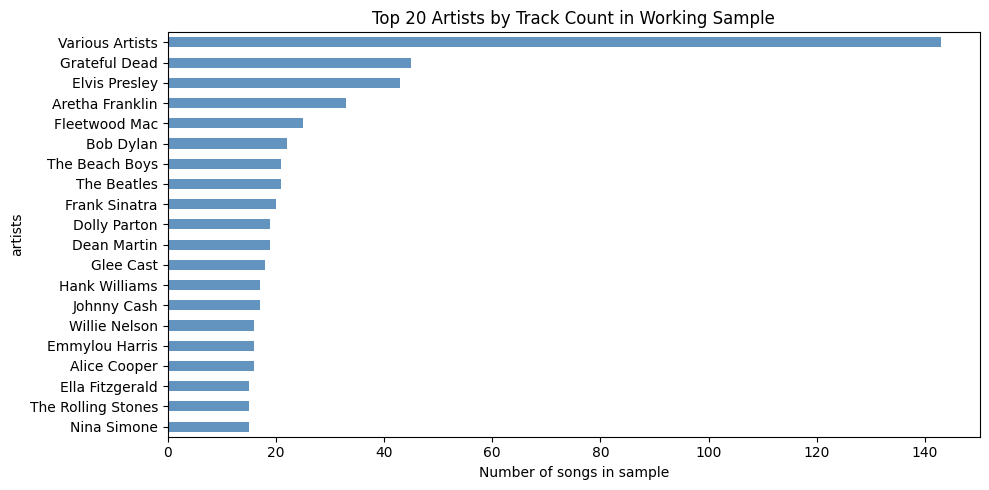

Top artist  : Various Artists  (143 songs)
Median tracks per artist : 1
Artists with only 1 song : 10,778


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
top_artists = df[COL_ARTIST].value_counts().head(20)
top_artists.sort_values().plot(kind="barh", ax=ax, color="steelblue", alpha=0.85)
ax.set_xlabel("Number of songs in sample")
ax.set_title("Top 20 Artists by Track Count in Working Sample")
plt.tight_layout()
plt.show()

print(f"Top artist  : {top_artists.index[0]}  ({top_artists.iloc[0]} songs)")
print(f"Median tracks per artist : {df[COL_ARTIST].value_counts().median():.0f}")
print(f"Artists with only 1 song : {(df[COL_ARTIST].value_counts() == 1).sum():,}")

---
## 4. Audio Feature Distributions

Each song carries 9 continuous audio descriptors computed by Spotify's audio analysis:

| Feature | Description |
|---|---|
| `danceability` | How suitable for dancing (0–1) |
| `energy` | Perceptual intensity and activity (0–1) |
| `loudness` | Overall loudness in dB (typically −60–0) |
| `speechiness` | Presence of spoken words (0–1) |
| `acousticness` | Confidence the track is acoustic (0–1) |
| `instrumentalness` | Predicts no vocals (0–1) |
| `liveness` | Audience presence in recording (0–1) |
| `valence` | Musical positiveness (0–1) |
| `tempo` | Estimated BPM |

We plot the distribution of each feature to understand its range, skew, and spread.

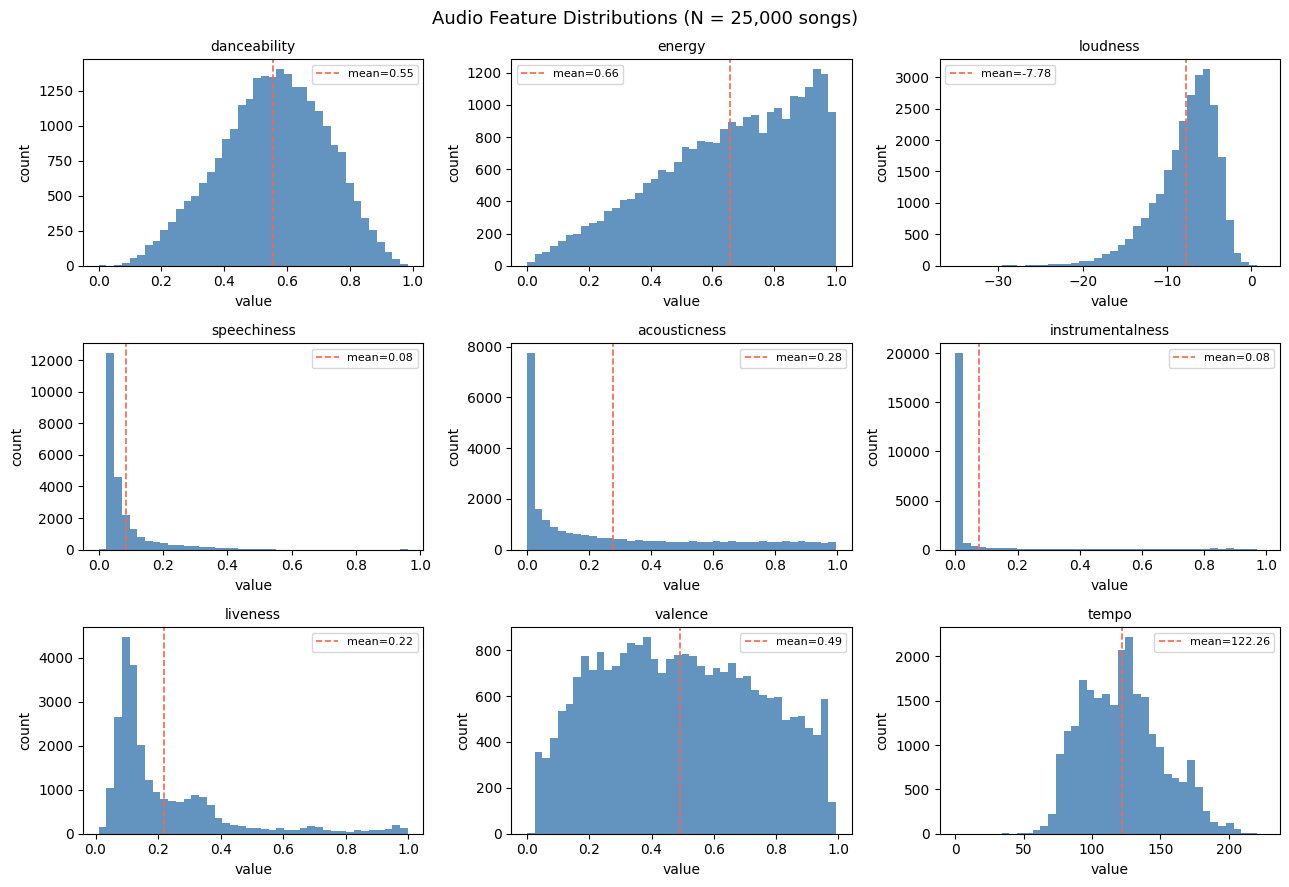

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(13, 9))
fig.suptitle("Audio Feature Distributions (N = {:,} songs)".format(len(df)), fontsize=13)

for ax, col in zip(axes.flat, AUDIO_COLS):
    data = df[col].dropna()
    ax.hist(data, bins=40, color="steelblue", edgecolor="none", alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("value")
    ax.set_ylabel("count")
    ax.axvline(data.mean(), color="tomato", linestyle="--", linewidth=1.2, label=f"mean={data.mean():.2f}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
# Summary statistics for audio features
df[AUDIO_COLS].describe().round(3)

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,25000.000,25000.000,25000.000,25000.000,25000.000,25000.000,25000.000,25000.000,25000.000
mean,0.554,0.656,-7.780,0.085,0.276,0.078,0.219,0.493,122.263
std,0.169,0.236,3.714,0.095,0.307,0.206,0.194,0.252,29.223
min,0.000,0.000,-35.098,0.000,0.000,0.000,0.010,0.000,0.000
25%,0.440,0.492,-9.669,0.035,0.011,0.000,0.098,0.286,99.338
50%,0.561,0.690,-7.028,0.048,0.137,0.000,0.137,0.483,120.614
75%,0.679,0.859,-5.140,0.089,0.500,0.007,0.285,0.695,140.076
max,0.984,1.000,1.559,0.961,0.996,0.994,0.999,0.993,226.130


Some observations
- `speechiness` and `instrumentalness` are heavily right-skewed — most songs cluster near 0.
- `loudness` spans a wide range; modern tracks tend to cluster near −5 to −10 dB.
- `tempo` is bimodal — many tracks sit around 80–100 BPM or 120–140 BPM (common time signatures).
- `valence` is relatively uniform — songs span the full happy-to-sad spectrum.

---
## 5. Audio Feature Correlations

Are some audio features measuring the same underlying property?
A correlation matrix reveals redundancy before we build representations.

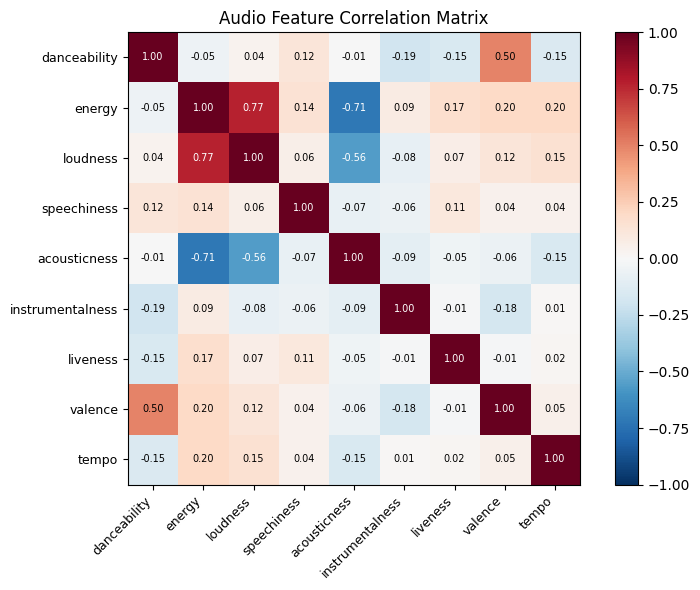

Strongest positive correlation:
energy        loudness    0.766762
danceability  valence     0.498603
energy        tempo       0.200998

Strongest negative correlation:
danceability  instrumentalness   -0.187921
loudness      acousticness       -0.556713
energy        acousticness       -0.711495


In [13]:
audio_corr = df[AUDIO_COLS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(audio_corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(AUDIO_COLS)))
ax.set_xticklabels(AUDIO_COLS, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(AUDIO_COLS)))
ax.set_yticklabels(AUDIO_COLS, fontsize=9)

for i in range(len(AUDIO_COLS)):
    for j in range(len(AUDIO_COLS)):
        ax.text(j, i, f"{audio_corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(audio_corr.values[i, j]) > 0.5 else "black")

plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Audio Feature Correlation Matrix")
plt.tight_layout()
plt.show()

print("Strongest positive correlation:")
corr_pairs = audio_corr.unstack().drop_duplicates().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]
print(corr_pairs.head(3).to_string())
print("\nStrongest negative correlation:")
print(corr_pairs.tail(3).to_string())

Observations:
- As a sanity check, this make sense -- songs that are loud are usually energetic. And these type of songs often convey a lot of positiveness (valence). 
- Some audio features are strongly correlated to one another. We might want to include only one or another in downstream tasks if efficiency is a concern. 

---
## 6. Lyrics Word Count Distribution

Lyrics quality varies widely. Very short lyrics (< 50 words) are often incomplete scrapes;
very long ones (> 700 words) may have repeated chorus/bridge sections.

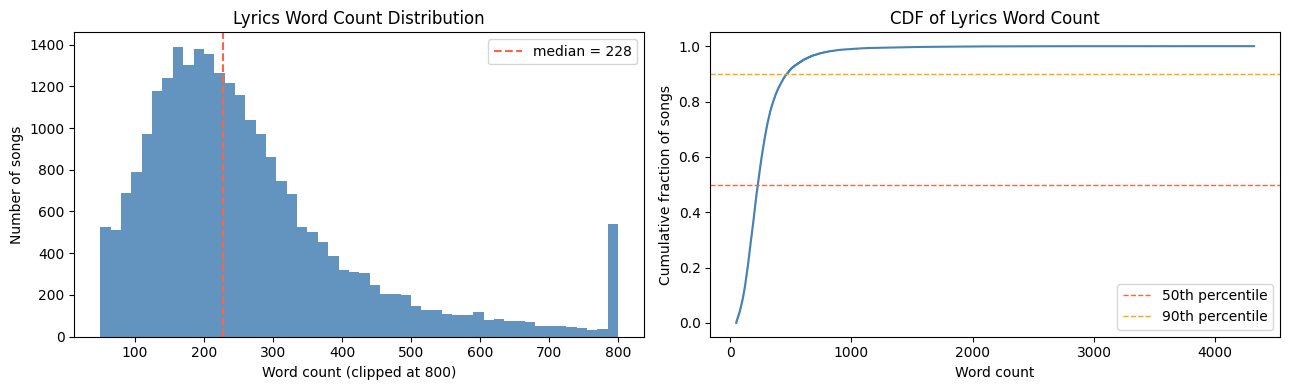

Median word count : 228
90th percentile   : 468
Songs > 500 words : 2,065 (8.3%)


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df["wc"].clip(upper=800), bins=50, color="steelblue", edgecolor="none", alpha=0.85)
axes[0].set_xlabel("Word count (clipped at 800)")
axes[0].set_ylabel("Number of songs")
axes[0].set_title("Lyrics Word Count Distribution")
axes[0].axvline(df["wc"].median(), color="tomato", linestyle="--", linewidth=1.5,
                label=f"median = {df['wc'].median():.0f}")
axes[0].legend()

# Cumulative distribution
sorted_wc = df["wc"].sort_values().values
axes[1].plot(sorted_wc, np.linspace(0, 1, len(sorted_wc)), color="steelblue")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Cumulative fraction of songs")
axes[1].set_title("CDF of Lyrics Word Count")
axes[1].axhline(0.5, color="tomato", linestyle="--", linewidth=1, label="50th percentile")
axes[1].axhline(0.9, color="orange", linestyle="--", linewidth=1, label="90th percentile")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Median word count : {df['wc'].median():.0f}")
print(f"90th percentile   : {df['wc'].quantile(0.9):.0f}")
print(f"Songs > 500 words : {(df['wc'] > 500).sum():,} ({(df['wc'] > 500).mean()*100:.1f}%)")

---
## 7. Key and Mode Distribution

Musical key (C through B = 12 pitches) and mode (major = bright, minor = dark)
are categorical variables. We visualize how they're distributed across the sample.

> **Note:** Pop music is often said to favor C major and G major — let's see if the data agrees.

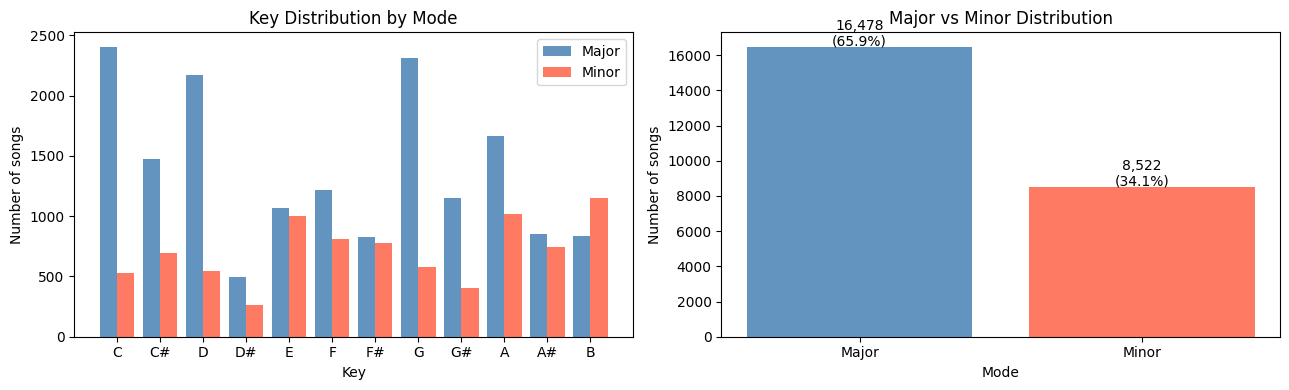

In [15]:
key_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Key distribution (major vs minor split)
key_major = df[df["mode_clean"] == 1]["key_clean"].value_counts().reindex(range(12), fill_value=0)
key_minor = df[df["mode_clean"] == 0]["key_clean"].value_counts().reindex(range(12), fill_value=0)
x = np.arange(12)
w = 0.4
axes[0].bar(x - w/2, key_major.values, width=w, label="Major", color="steelblue", alpha=0.85)
axes[0].bar(x + w/2, key_minor.values, width=w, label="Minor", color="tomato", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(key_names)
axes[0].set_xlabel("Key")
axes[0].set_ylabel("Number of songs")
axes[0].set_title("Key Distribution by Mode")
axes[0].legend()

# Mode distribution
mode_counts = df["mode_clean"].map({1: "Major", 0: "Minor"}).value_counts()
axes[1].bar(mode_counts.index, mode_counts.values, color=["steelblue", "tomato"], alpha=0.85)
axes[1].set_xlabel("Mode")
axes[1].set_ylabel("Number of songs")
axes[1].set_title("Major vs Minor Distribution")
for i, (label, val) in enumerate(mode_counts.items()):
    axes[1].text(i, val + 50, f"{val:,}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

---
## 8. Summary: What to Remember Going Forward

| Observation | Implication for modeling |
|---|---|
| A few artists dominate | Artist-level embeddings may be biased toward popular artists |
| `speechiness` & `instrumentalness` are right-skewed | Standardization is critical before distance computation |
| `energy` and `loudness` are positively correlated | These features carry redundant information |
| Median lyrics ~ 200–300 words | Enough text for TF-IDF; sparse for Word2Vec on rare words |
| Major mode outnumbers minor | One-hot encoding needed; treating as numeric (0/1) loses key information |

We will pay attention to these observations in developing the models moving forward.